In [1]:
import pandas as pd
import psycopg2
import getpass

# Te pedirá la contraseña de forma segura al ejecutar (no se guarda en el notebook)
db_password = getpass.getpass("Ingresa tu contraseña de PostgreSQL: ")

conn = psycopg2.connect(
    host="localhost",
    database="olist_store",
    user="postgres",
    password=db_password,
    port=5432
)

print("✅ Conexión exitosa a PostgreSQL")

Ingresa tu contraseña de PostgreSQL:  ········


✅ Conexión exitosa a PostgreSQL


In [18]:
# Pregunta 1: ¿Cuáles son las categorías con más ingresos?

query_q1 = """
SELECT 
    p.product_category_name AS categoria,
    COUNT(oi.order_item_id) AS num_ventas,
    SUM(oi.price) AS ingresos_totales,
    ROUND(AVG(oi.price), 2) AS precio_promedio
FROM products p
INNER JOIN order_items oi
  ON p.product_id = oi.product_id
GROUP BY p.product_category_name
ORDER BY ingresos_totales DESC
LIMIT 15
"""

# Traer datos en un DataFrame
df_q1 = pd.read_sql(query_q1, conn)

# Ver los datos
print(df_q1)

                 categoria  num_ventas  ingresos_totales  precio_promedio
0             beleza_saude        9670        1258681.34           130.16
1       relogios_presentes        5991        1205005.68           201.14
2          cama_mesa_banho       11115        1036988.68            93.30
3            esporte_lazer        8641         988048.97           114.34
4   informatica_acessorios        7827         911954.32           116.51
5         moveis_decoracao        8334         729762.49            87.56
6               cool_stuff        3796         635290.85           167.36
7    utilidades_domesticas        6964         632248.66            90.79
8               automotivo        4235         592720.11           139.96
9       ferramentas_jardim        4347         485256.46           111.63
10              brinquedos        4117         483946.60           117.55
11                   bebes        3065         411764.89           134.34
12              perfumaria        3419

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_26184\557978914.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q1 = pd.read_sql(query_q1, conn)


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_26316\2526288400.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_q1,


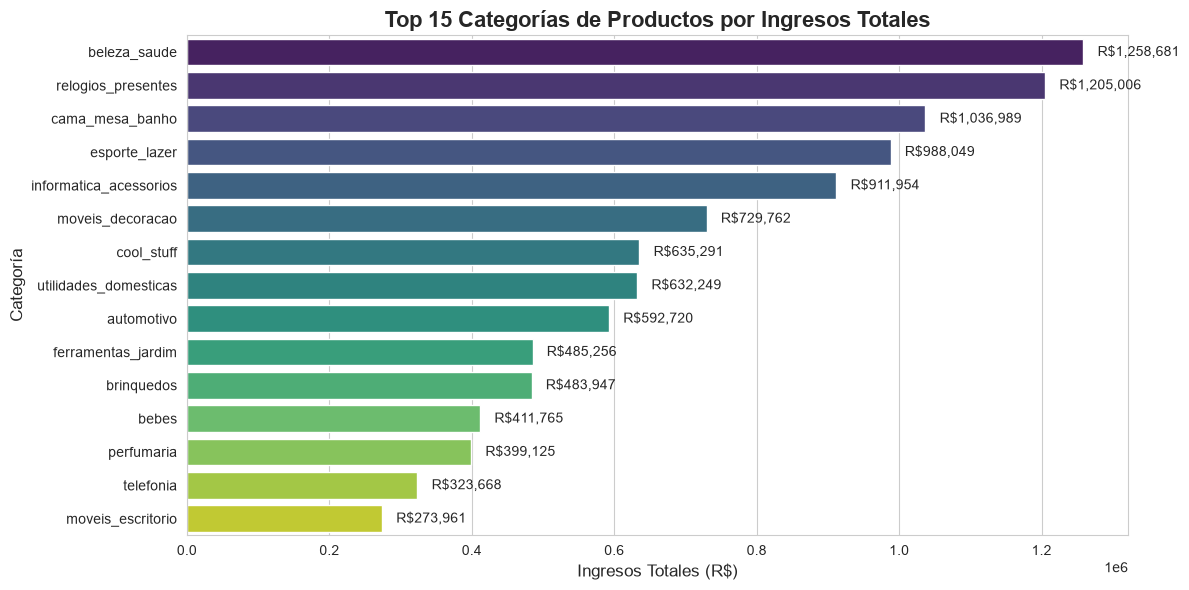

FileNotFoundError: [Errno 2] No such file or directory: 'visualizations/01_categorias_ingresos.png'

<Figure size 1200x600 with 0 Axes>

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de las gráficas
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Crear la figura
plt.figure(figsize=(12, 6))

# Crear gráfica de barras
sns.barplot(data=df_q1, 
            x='ingresos_totales', 
            y='categoria', 
            palette='viridis')

# Personalizar la gráfica
plt.title('Top 15 Categorías de Productos por Ingresos Totales', fontsize=16, fontweight='bold')
plt.xlabel('Ingresos Totales (R$)', fontsize=12)
plt.ylabel('Categoría', fontsize=12)

# Mostrar valores en las barras
for i, v in enumerate(df_q1['ingresos_totales']):
    plt.text(v + 20000, i, f'R${v:,.0f}', va='center')

plt.tight_layout()
plt.show()

# Guardar la imagen
plt.savefig('visualizations/01_categorias_ingresos.png', dpi=300, bbox_inches='tight')
print("✅ Gráfica guardada en visualizations/01_categorias_ingresos.png")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

query_q1_english = """
SELECT 
    COALESCE(t.product_category_name_english, p.product_category_name) AS categoria,
    COUNT(oi.order_item_id) AS num_ventas,
    SUM(oi.price) AS ingresos_totales,
    ROUND(AVG(oi.price), 2) AS precio_promedio
FROM products p
INNER JOIN order_items oi
  ON p.product_id = oi.product_id
LEFT JOIN product_category_name_translation t
  ON p.product_category_name = t.product_category_name
GROUP BY COALESCE(t.product_category_name_english, p.product_category_name)
ORDER BY ingresos_totales DESC
LIMIT 10
"""

df_q1_en = pd.read_sql(query_q1_english, conn)
df_q1_en['categoria'] = df_q1_en['categoria'].str.replace('_', ' ').str.title()

sns.set_style("white")
plt.figure(figsize=(12, 6))

ax = sns.barplot(data=df_q1_en, 
                  x='ingresos_totales', 
                  y='categoria', 
                  palette='viridis')

ax.set_ylabel('')
plt.title('Top 10 Product Categories by Total Revenue', 
          fontsize=16, fontweight='bold', pad=25)

# Quitar el eje X completo (números y etiqueta)
ax.set_xlabel('')
ax.set_xticks([])

ax.grid(False)
sns.despine(left=True, bottom=True)

for i, v in enumerate(df_q1_en['ingresos_totales']):
    plt.text(v + 20000, i, f'R${v:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('visualizations/01_categorias_ingresos.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfica actualizada y guardada")

plt.tight_layout()
plt.savefig('visualizations/01_categorias_ingresos.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfica actualizada y guardada")

In [5]:
query_q2 = """
SELECT 
    c.customer_state,
    COUNT(*) AS num_ordenes,
    ROUND(AVG(EXTRACT(DAY FROM (o.order_delivered_customer_date - o.order_purchase_timestamp))), 2) AS promedio_dias_entrega
FROM orders o
INNER JOIN customers c
  ON o.customer_id = c.customer_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY c.customer_state
ORDER BY promedio_dias_entrega DESC
limit 10 ;
"""

# Traer datos en un DataFrame
df_q2 = pd.read_sql(query_q2, conn)

# Ver los datos
print(df_q2)

  customer_state  num_ordenes  promedio_dias_entrega
0             RR           41                  28.98
1             AP           67                  26.73
2             AM          145                  25.99
3             AL          397                  24.04
4             PA          946                  23.32
5             MA          717                  21.12
6             SE          335                  21.03
7             CE         1279                  20.82
8             AC           80                  20.64
9             PB          517                  19.95


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_26316\2775447061.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q2 = pd.read_sql(query_q2, conn)


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_26316\782753652.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_q2,


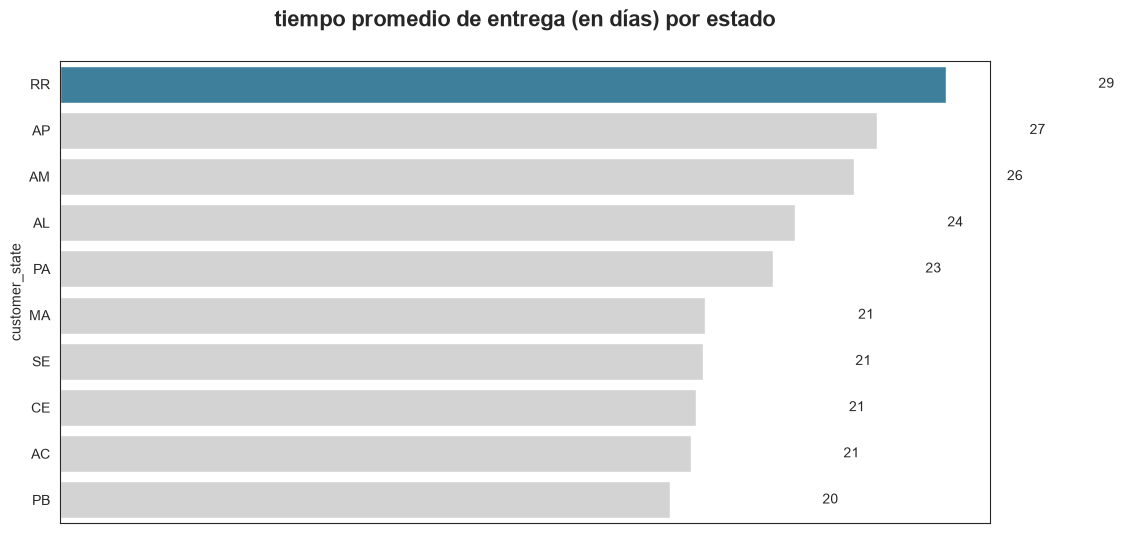

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de las gráficas
sns.set_style("white")
plt.rcParams['figure.figsize'] = (12, 6)

colors = ['#2E86AB' if i == 0 else '#D3D3D3' for i in range(len(df_q2))]

# Crear gráfica de barras
ax = sns.barplot(data=df_q2, 
            x='promedio_dias_entrega', 
            y='customer_state', 
            palette=colors)

for i, v in enumerate(df_q2['promedio_dias_entrega']):
    plt.text(v + 5, i, f'{v:,.0f}', va='center', fontsize=10)

# Quitar el eje X completo (números y etiqueta)
ax.set_xlabel('')
ax.set_xticks([])

# Personalizar la gráfica
plt.title('tiempo promedio de entrega (en días) por estado', fontsize=16, fontweight='bold', pad=25)

plt.show()

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_26316\1913759016.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_q2,


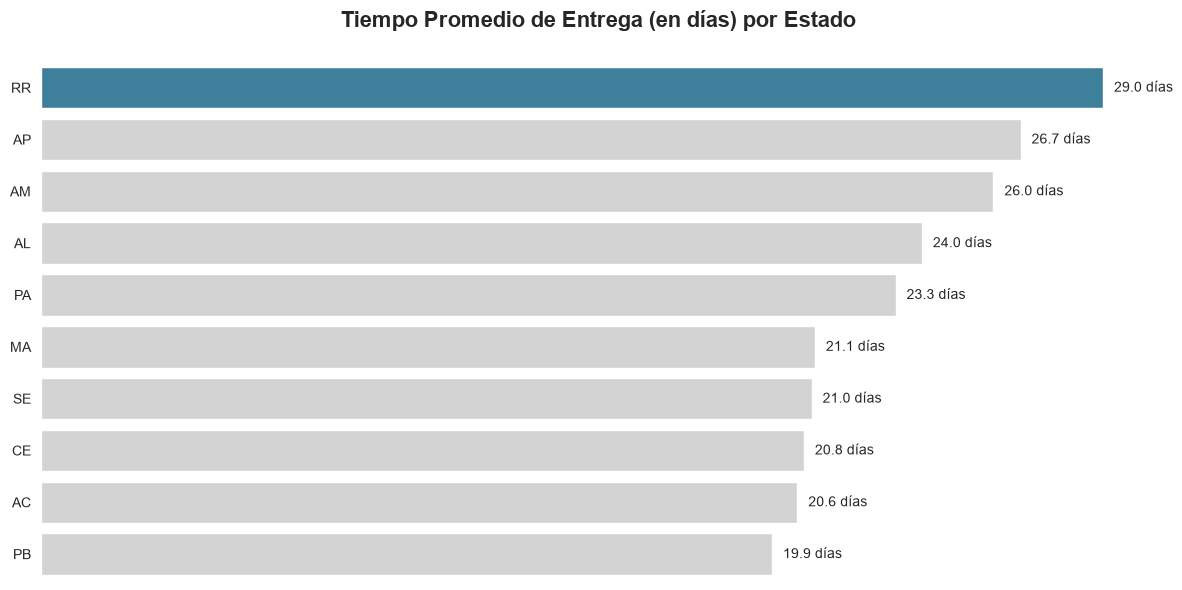

✅ Gráfica guardada


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el estilo de las gráficas
sns.set_style("white")
plt.rcParams['figure.figsize'] = (12, 6)

colors = ['#2E86AB' if i == 0 else '#D3D3D3' for i in range(len(df_q2))]

# Crear gráfica de barras
ax = sns.barplot(data=df_q2, 
            x='promedio_dias_entrega', 
            y='customer_state', 
            palette=colors)

for i, v in enumerate(df_q2['promedio_dias_entrega']):
    plt.text(v + 0.3, i, f'{v:.1f} días', va='center', fontsize=10)

# Quitar el eje X completo (números y etiqueta)
ax.set_xlabel('')
ax.set_xticks([])
ax.set_ylabel('')

# Personalizar la gráfica
plt.title('Tiempo Promedio de Entrega (en días) por Estado', fontsize=16, fontweight='bold', pad=25)

sns.despine(left=True, bottom=True)
ax.grid(False)

plt.tight_layout()
plt.savefig('../visualizations/02_entrega_por_estado.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfica guardada")

In [15]:
import os
print(os.getcwd())

C:\Users\USUARIO\Desktop\olist-ecommerce-analysis\notebooks


In [4]:
query_q3 = """
WITH compras_por_cliente AS (
    SELECT 
        customer_unique_id,
        COUNT(o.order_id) AS num_compras
    FROM customers c
    INNER JOIN orders o
      ON c.customer_id = o.customer_id
    GROUP BY customer_unique_id
)

SELECT 
    CASE 
        WHEN num_compras = 1 THEN 'Compra única'
        ELSE '2+ compras'
    END AS tipo_cliente,
    COUNT(*) AS num_clientes,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS porcentaje
FROM compras_por_cliente
GROUP BY tipo_cliente;
"""

# Traer datos en un DataFrame
df_q3= pd.read_sql(query_q3, conn)

# Ver los datos
print(df_q3)

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_8224\778251148.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q3= pd.read_sql(query_q3, conn)


   tipo_cliente  num_clientes  porcentaje
0    2+ compras          2997        3.12
1  Compra única         93099       96.88


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_8224\2729345362.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q3 = pd.read_sql(query_q3, conn)


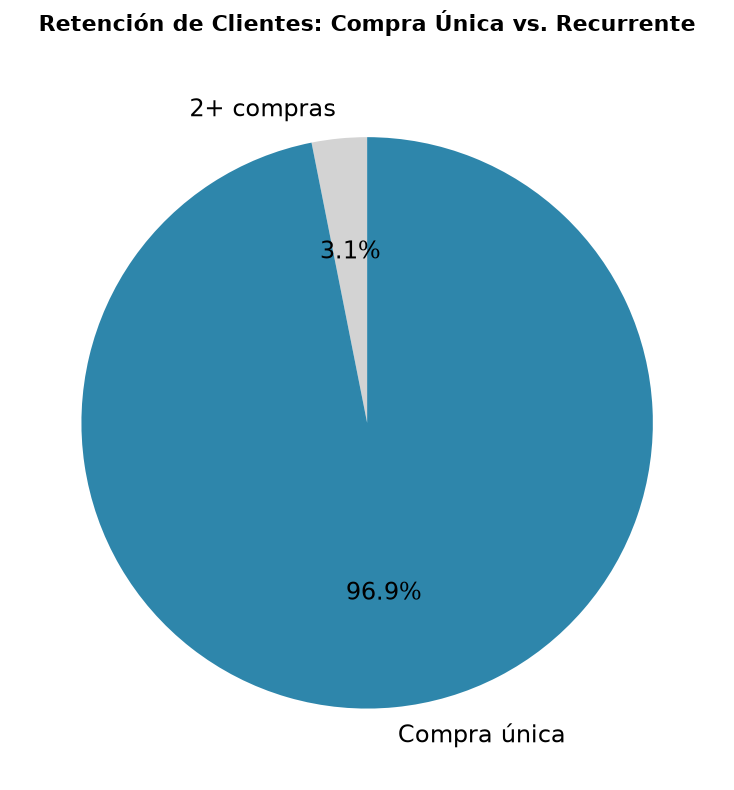

✅ Gráfica guardada


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df_q3 = pd.read_sql(query_q3, conn)

# Color basado en el CONTENIDO de la fila, no en su posición/índice
colors = ['#2E86AB' if valor == 'Compra única' else '#D3D3D3' for valor in df_q3['tipo_cliente']]

plt.figure(figsize=(10, 8))
plt.pie(df_q3['num_clientes'], 
        labels=df_q3['tipo_cliente'], 
        autopct='%1.1f%%', 
        colors=colors,
        startangle=90,
        textprops={'fontsize':17})

plt.title('Retención de Clientes: Compra Única vs. Recurrente', 
          fontsize=16, fontweight='bold', pad=25)

plt.tight_layout()
plt.savefig('../visualizations/03_retencion_clientes.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfica guardada")



In [12]:
query_q4 = """
SELECT 
    orv.review_score,
    COUNT(*) AS num_reviews,
    ROUND(AVG(EXTRACT(DAY FROM (o.order_delivered_customer_date - o.order_purchase_timestamp))), 2) AS promedio_dias_entrega
FROM orders o
INNER JOIN order_reviews orv
  ON o.order_id = orv.order_id
WHERE o.order_delivered_customer_date IS NOT NULL
GROUP BY orv.review_score
ORDER BY orv.review_score ASC;
"""

# Traer datos en un DataFrame
df_q4 = pd.read_sql(query_q4, conn)

# Ver los datos
print(df_q4)

   review_score  num_reviews  promedio_dias_entrega
0             1         9295                  20.89
1             2         2908                  16.19
2             3         7885                  13.79
3             4        18861                  11.84
4             5        56658                  10.21


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_26184\438608712.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q4 = pd.read_sql(query_q4, conn)


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_26184\3161864657.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q4 = pd.read_sql(query_q4, conn)


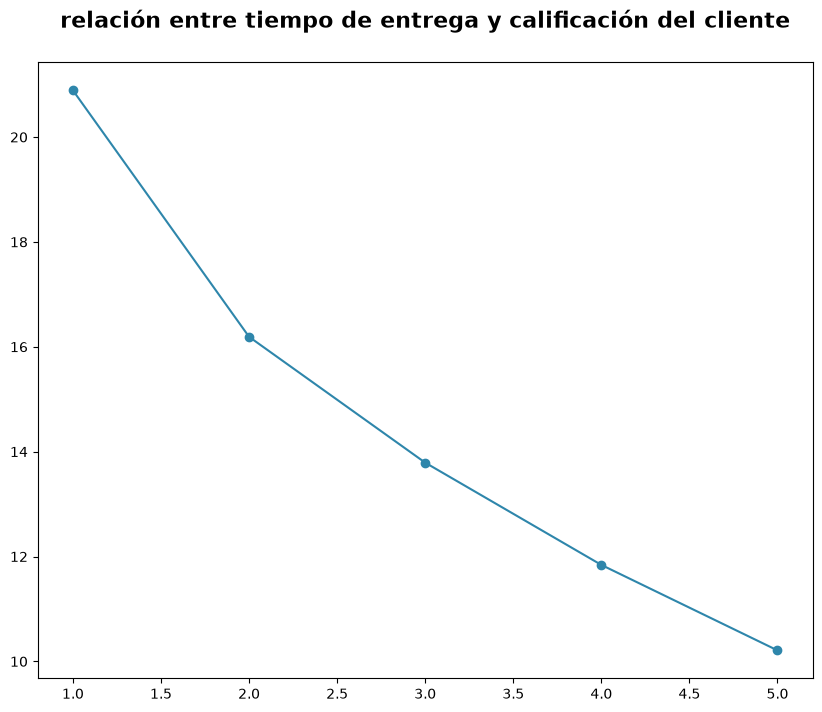

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

df_q4 = pd.read_sql(query_q4, conn)

# Color basado en el CONTENIDO de la fila, no en su posición/índice

plt.figure(figsize=(10, 8))
plt.plot(df_q4['review_score'],
        df_q4['promedio_dias_entrega'],
        color='#2E86AB',
        marker='o')

plt.title('relación entre tiempo de entrega y calificación del cliente', 
          fontsize=16, fontweight='bold', pad=25)

plt.show()



C:\Users\USUARIO\AppData\Local\Temp\ipykernel_26184\2447637824.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q4 = pd.read_sql(query_q4, conn)


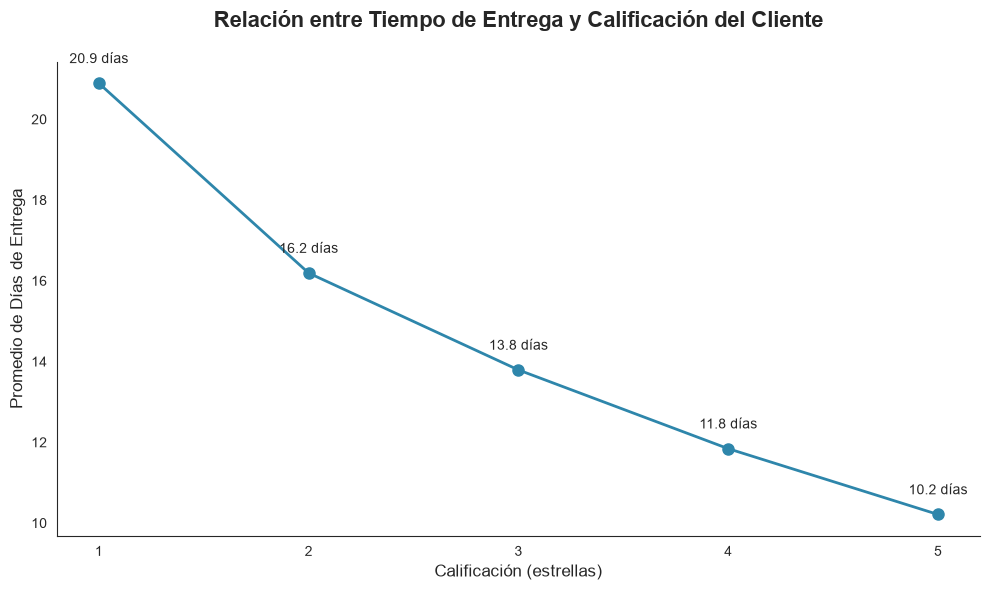

✅ Gráfica guardada


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

df_q4 = pd.read_sql(query_q4, conn)

sns.set_style("white")
plt.figure(figsize=(10, 6))

plt.plot(df_q4['review_score'], df_q4['promedio_dias_entrega'], 
         color='#2E86AB', marker='o', linewidth=2, markersize=8)

# Valores exactos siguiendo cada punto (arriba)
for i, row in df_q4.iterrows():
    plt.text(row['review_score'], row['promedio_dias_entrega'] + 0.5, 
              f"{row['promedio_dias_entrega']:.1f} días", 
              ha='center', fontsize=10)

# Eje X con valores exactos (1,2,3,4,5)
plt.xticks([1, 2, 3, 4, 5])

# Quitar bordes de arriba y derecha
sns.despine()

plt.title('Relación entre Tiempo de Entrega y Calificación del Cliente', 
          fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Calificación (estrellas)', fontsize=12)
plt.ylabel('Promedio de Días de Entrega', fontsize=12)

plt.tight_layout()
plt.savefig('../visualizations/04_entrega_vs_rating.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfica guardada")

In [2]:
query_q5 = """
SELECT
    DATE_TRUNC('month', o.order_purchase_timestamp) AS mes,
    COUNT(DISTINCT o.order_id) AS num_ordenes,
    COUNT(DISTINCT o.customer_id) AS clientes_unicos,
    ROUND(SUM(oi.price), 2) AS ingresos_totales,
    ROUND(AVG(oi.price), 2) AS ticket_promedio
FROM orders o
INNER JOIN order_items oi
  ON o.order_id = oi.order_id
GROUP BY DATE_TRUNC('month', o.order_purchase_timestamp)
ORDER BY mes ASC;
"""

# Traer datos en un DataFrame
df_q5 = pd.read_sql(query_q5, conn)

# Ver los datos
print(df_q5)

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_1876\2584632115.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q5 = pd.read_sql(query_q5, conn)


          mes  num_ordenes  clientes_unicos  ingresos_totales  ticket_promedio
0  2016-09-01            3                3            267.36            44.56
1  2016-10-01          308              308          49507.66           136.38
2  2016-12-01            1                1             10.90            10.90
3  2017-01-01          789              789         120312.87           125.98
4  2017-02-01         1733             1733         247303.02           126.76
5  2017-03-01         2641             2641         374344.30           124.78
6  2017-04-01         2391             2391         359927.23           134.10
7  2017-05-01         3660             3660         506071.14           122.36
8  2017-06-01         3217             3217         433038.60           120.86
9  2017-07-01         3969             3969         498031.48           110.21
10 2017-08-01         4293             4293         573971.68           116.90
11 2017-09-01         4243             4243         

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_1876\508558614.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_q5 = pd.read_sql(query_q5, conn)


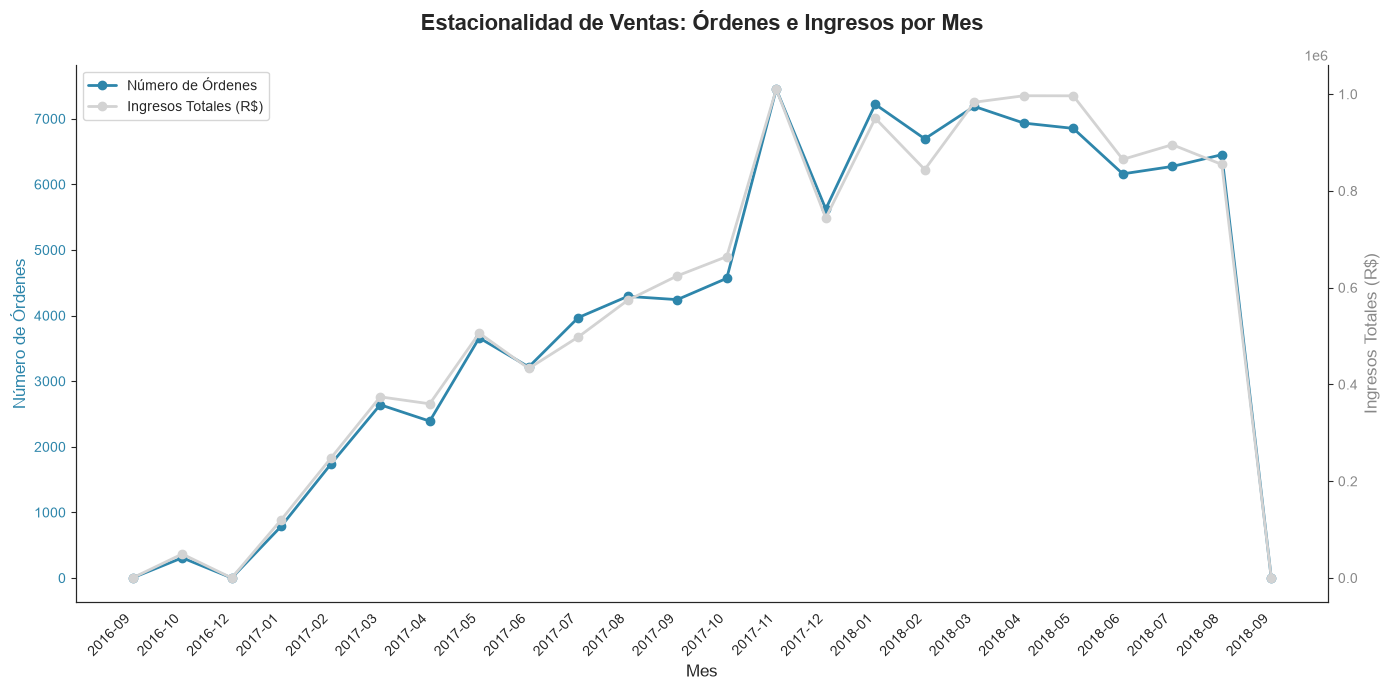

✅ Gráfica guardada


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

df_q5 = pd.read_sql(query_q5, conn)

# Formatear la fecha como 'YYYY-MM' (ej: 2017-10)
df_q5['mes_label'] = df_q5['mes'].dt.strftime('%Y-%m')

sns.set_style("white")
fig, ax1 = plt.subplots(figsize=(14, 7))

# Línea 1: Número de órdenes (eje izquierdo)
color1 = '#2E86AB'
ax1.plot(df_q5['mes_label'], df_q5['num_ordenes'], 
         color=color1, marker='o', linewidth=2, markersize=6, label='Número de Órdenes')
ax1.set_xlabel('Mes', fontsize=12)
ax1.set_ylabel('Número de Órdenes', fontsize=12, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# Línea 2: Ingresos totales (eje derecho)
ax2 = ax1.twinx()
color2 = '#D3D3D3'
ax2.plot(df_q5['mes_label'], df_q5['ingresos_totales'], 
         color=color2, marker='o', linewidth=2, markersize=6, label='Ingresos Totales (R$)')
ax2.set_ylabel('Ingresos Totales (R$)', fontsize=12, color='#888888')
ax2.tick_params(axis='y', labelcolor='#888888')

# Rotar labels del eje X para que no se amontonen
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

plt.title('Estacionalidad de Ventas: Órdenes e Ingresos por Mes', 
          fontsize=16, fontweight='bold', pad=25)

sns.despine(right=False)

# Leyenda combinada de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('../visualizations/05_estacionalidad_ventas.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfica guardada")

In [4]:
SELECT MIN(order_purchase_timestamp), MAX(order_purchase_timestamp)
FROM orders;

SyntaxError: invalid syntax (217358969.py, line 1)